# 01 — Разведочный анализ данных (NIJ Recidivism Challenge)

**Датасет:** 25 835 человек, освобождённых из тюрем штата Джорджия на условно-досрочное наблюдение (2013–2015).
**Целевые переменные:** арест в течение 1 / 2 / 3 лет после освобождения (`Recidivism_Arrest_Year1/2/3`, `Recidivism_Within_3years`).
**Источник:** NIJ Recidivism Forecasting Challenge (2021), официальный train/test сплит в колонке `Training_Sample`.

Соответствует п. 3 календарного плана ИПМ: *«Сбор и предварительная обработка данных, разработка концептуальной модели»*.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from recidivism.data import load_nij_raw, preprocess_nij, NIJ_TARGET_YEARS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

raw = load_nij_raw("../data/raw/nij_recidivism_full.csv")
print(raw.shape)
raw.head(3)

(25835, 54)


,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,False,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.44761,False,False,False,False,False,1
1,2,M,BLACK,33-37,16,False,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.00000,False,True,False,False,True,1
2,3,M,BLACK,48 or older,24,False,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.00000,False,True,False,True,False,1


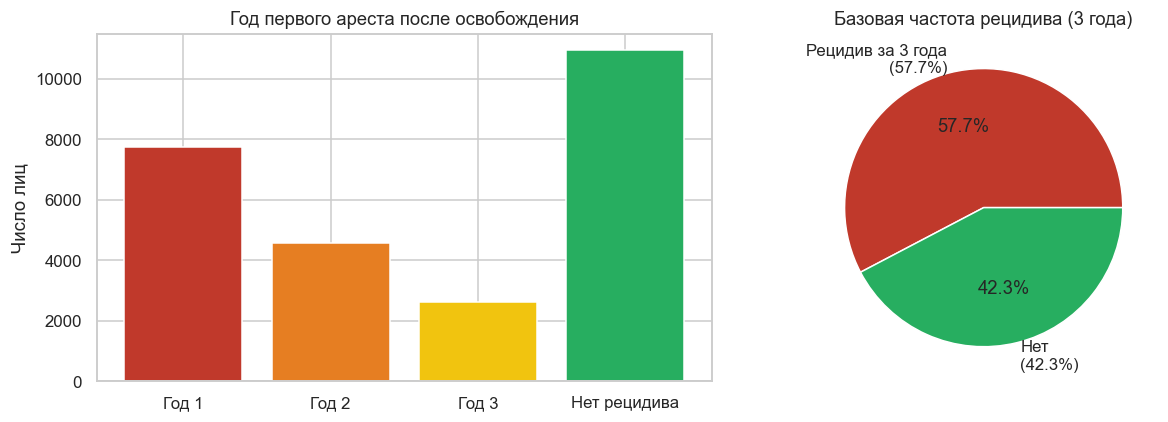

In [2]:
# Распределение целевых переменных: в каком году происходит первый арест
def to01(s):
    return s.map({True: 1, False: 0, "TRUE": 1, "FALSE": 0, "true": 1, "false": 0}).astype(int)

targets = pd.DataFrame({c: to01(raw[c]) for c in NIJ_TARGET_YEARS})
targets["No recidivism (3y)"] = 1 - targets.sum(axis=1).clip(upper=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = targets.sum()
axes[0].bar(["Год 1", "Год 2", "Год 3", "Нет рецидива"], counts, color=["#c0392b", "#e67e22", "#f1c40f", "#27ae60"])
axes[0].set_title("Год первого ареста после освобождения")
axes[0].set_ylabel("Число лиц")

rate3y = to01(raw["Recidivism_Within_3years"]).mean()
axes[1].pie([rate3y, 1 - rate3y], labels=[f"Рецидив за 3 года\n({rate3y:.1%})", f"Нет\n({1-rate3y:.1%})"],
            colors=["#c0392b", "#27ae60"], autopct="%1.1f%%")
axes[1].set_title("Базовая частота рецидива (3 года)")
plt.tight_layout()
plt.show()

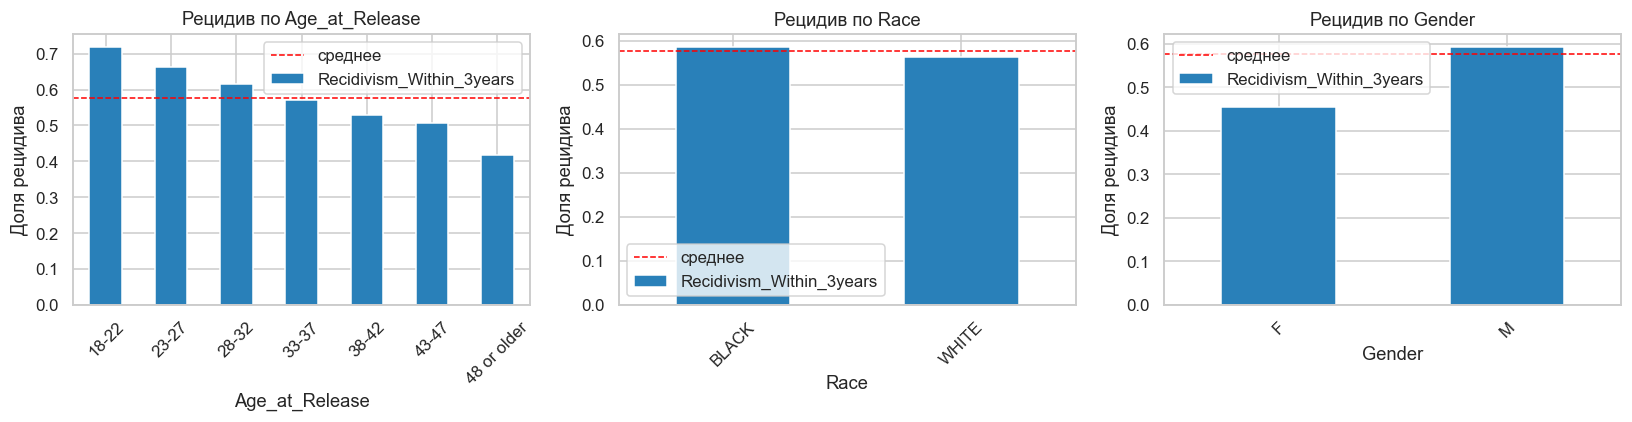

In [3]:
# Частота рецидива в разрезе социально-демографических групп
y3 = to01(raw["Recidivism_Within_3years"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age_at_Release", "Race", "Gender"]):
    rates = y3.groupby(raw[col]).mean().sort_index()
    rates.plot(kind="bar", ax=ax, color="#2980b9")
    ax.axhline(y3.mean(), color="red", ls="--", lw=1, label="среднее")
    ax.set_title(f"Рецидив по {col}")
    ax.set_ylabel("Доля рецидива")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

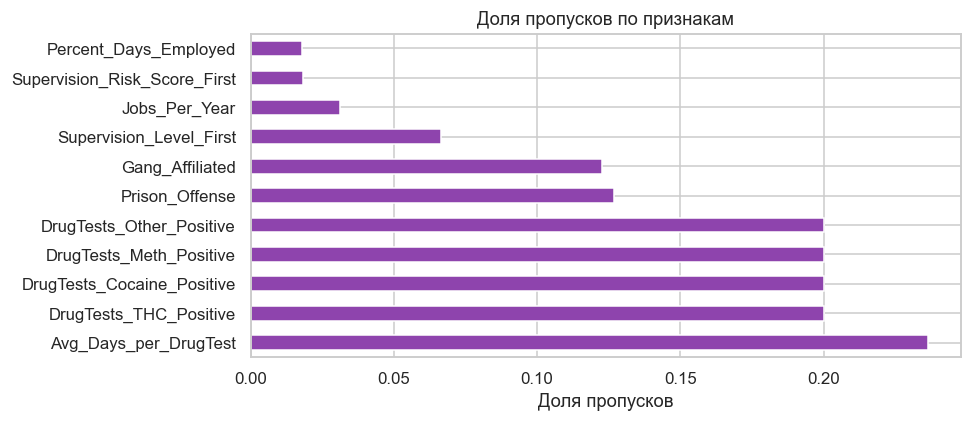

Признаков с пропусками: 11


In [4]:
# Пропуски в данных
missing = raw.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(9, 4))
missing.plot(kind="barh", color="#8e44ad")
plt.title("Доля пропусков по признакам")
plt.xlabel("Доля пропусков")
plt.tight_layout()
plt.show()

print("Признаков с пропусками:", len(missing))

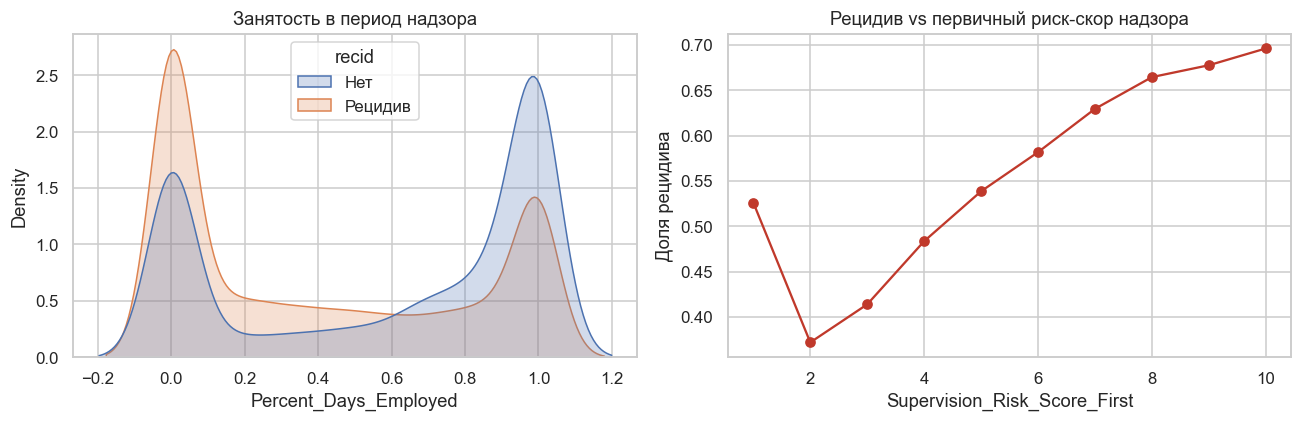

In [5]:
# Связь динамики периода надзора с рецидивом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=pd.DataFrame({"Percent_Days_Employed": raw["Percent_Days_Employed"], "recid": y3.map({1: "Рецидив", 0: "Нет"})}),
            x="Percent_Days_Employed", hue="recid", common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Занятость в период надзора")

risk = y3.groupby(raw["Supervision_Risk_Score_First"]).mean()
risk.plot(marker="o", ax=axes[1], color="#c0392b")
axes[1].set_title("Рецидив vs первичный риск-скор надзора")
axes[1].set_xlabel("Supervision_Risk_Score_First")
axes[1].set_ylabel("Доля рецидива")
plt.tight_layout()
plt.show()

Матрица признаков: (25835, 63)
Train/test (официальный сплит): 18028 / 7807


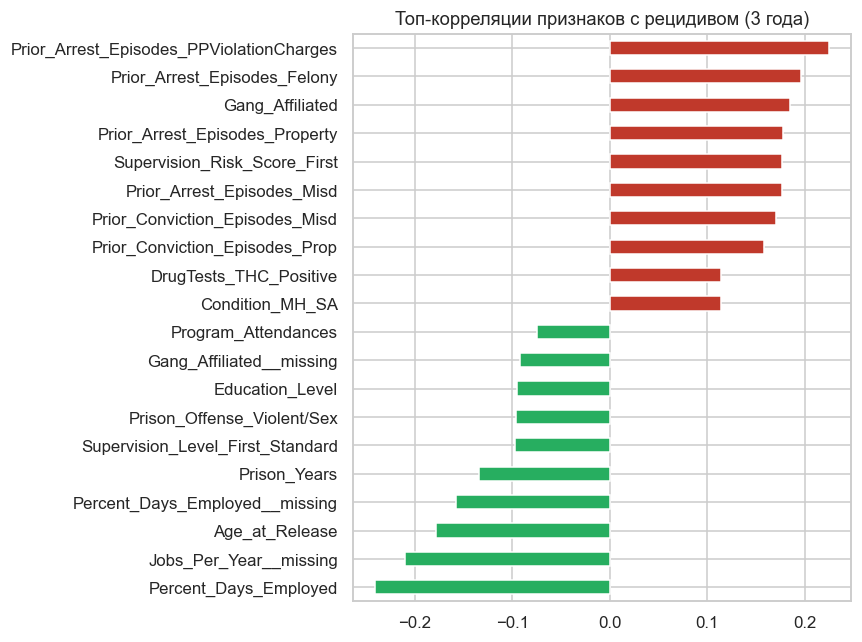

In [6]:
# Итог предобработки: численная матрица признаков (см. src/recidivism/data.py)
X, meta = preprocess_nij(raw)
print("Матрица признаков:", X.shape)
print("Train/test (официальный сплит):", (meta["Training_Sample"] == 1).sum(), "/", (meta["Training_Sample"] == 0).sum())

corr = X.corrwith(pd.Series(meta["Recidivism_Within_3years"].to_numpy(), index=X.index)).sort_values()
top = pd.concat([corr.head(10), corr.tail(10)])
plt.figure(figsize=(8, 6))
top.plot(kind="barh", color=np.where(top > 0, "#c0392b", "#27ae60"))
plt.title("Топ-корреляции признаков с рецидивом (3 года)")
plt.tight_layout()
plt.show()